# Notebook 04 — Visualization & Comparison

Generates final plots and comparison tables from Notebook 03's output CSVs.

In [8]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

WORKING_DIR = '/kaggle/working'

# Auto-detect all required files
def find_file(filename):
    matches = glob.glob(f'/kaggle/input/**/{filename}', recursive=True)
    return matches[0] if matches else None

# Find files (Kaggle sometimes renames files like 'results (1).csv')
results_path = find_file('results.csv') or find_file('results (1).csv')
predictions_path = find_file('predictions.csv')
qa_results_path = find_file('qa_results.csv')
corpus_path = find_file('reports_corpus.csv')
colpali_png_path = find_file('colpali_retrieval.png')
clip_png_path = find_file('clip_retrieval.png')

for name, path in [
    ('results', results_path),
    ('predictions', predictions_path),
    ('qa_results', qa_results_path),
    ('reports_corpus', corpus_path),
    ('colpali_retrieval.png', colpali_png_path),
    ('clip_retrieval.png', clip_png_path),
]:
    status = '✓' if path else '✗'
    print(f'  {status} {name}: {path}')

  ✓ results: /kaggle/input/datasets/mohammedtaha778/notebook3-results/results (1).csv
  ✓ predictions: /kaggle/input/datasets/mohammedtaha778/notebook3-results/predictions.csv
  ✓ qa_results: /kaggle/input/datasets/mohammedtaha778/notebook3-results/qa_results.csv
  ✓ reports_corpus: /kaggle/input/datasets/mohammedtaha778/reports-corpus/reports_corpus.csv
  ✓ colpali_retrieval.png: /kaggle/input/datasets/mohammedtaha778/output-images/colpali_retrieval.png
  ✓ clip_retrieval.png: /kaggle/input/datasets/mohammedtaha778/output-images/clip_retrieval.png


## 1. Comparison Table

In [9]:
results_df = pd.read_csv(results_path, index_col=0)
print('=== Report Generation Comparison ===\n')
print(results_df.round(4).to_markdown())

=== Report Generation Comparison ===

|                    |   BERTScore_P |   BERTScore_R |   BERTScore_F1 |   ROUGE-L |   RadGraph_F1 |
|:-------------------|--------------:|--------------:|---------------:|----------:|--------------:|
| ColPali + MedGemma |        0.4743 |        0.4743 |         0.4743 |    0.0933 |           nan |
| CLIP + MedGemma    |        0.459  |        0.459  |         0.459  |    0.0898 |           nan |
| MedGemma Direct    |        0.4614 |        0.4614 |         0.4614 |    0.075  |           nan |


## 2. BERTScore F1 Bar Chart

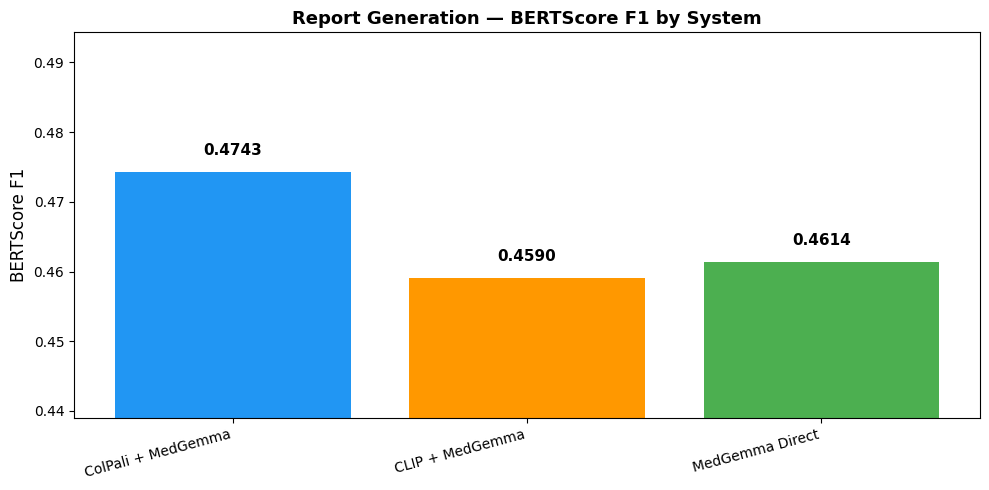

✓ Chart saved


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
systems = results_df.index.tolist()
scores = results_df['BERTScore_F1'].tolist()
colors = ['#2196F3', '#FF9800', '#4CAF50']
bars = ax.bar(systems, scores, color=colors[:len(systems)])

ax.set_ylabel('BERTScore F1', fontsize=12)
ax.set_title('Report Generation — BERTScore F1 by System', fontsize=13, fontweight='bold')
ax.set_ylim(min(scores) - 0.02, max(scores) + 0.02)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, 'bertscore_comparison.png'), dpi=150)
plt.show()
print('✓ Chart saved')

## 3. ROUGE-L Bar Chart

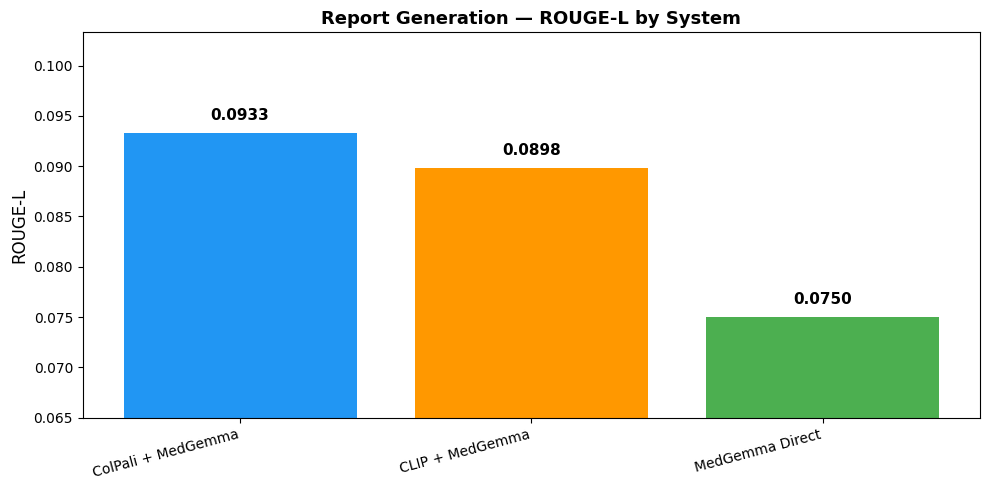

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
scores = results_df['ROUGE-L'].tolist()
bars = ax.bar(systems, scores, color=colors[:len(systems)])

ax.set_ylabel('ROUGE-L', fontsize=12)
ax.set_title('Report Generation — ROUGE-L by System', fontsize=13, fontweight='bold')
ax.set_ylim(min(scores) - 0.01, max(scores) + 0.01)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, 'rouge_comparison.png'), dpi=150)
plt.show()

## 4. ColPali vs CLIP Retrieval Comparison (Pre-saved PNGs)

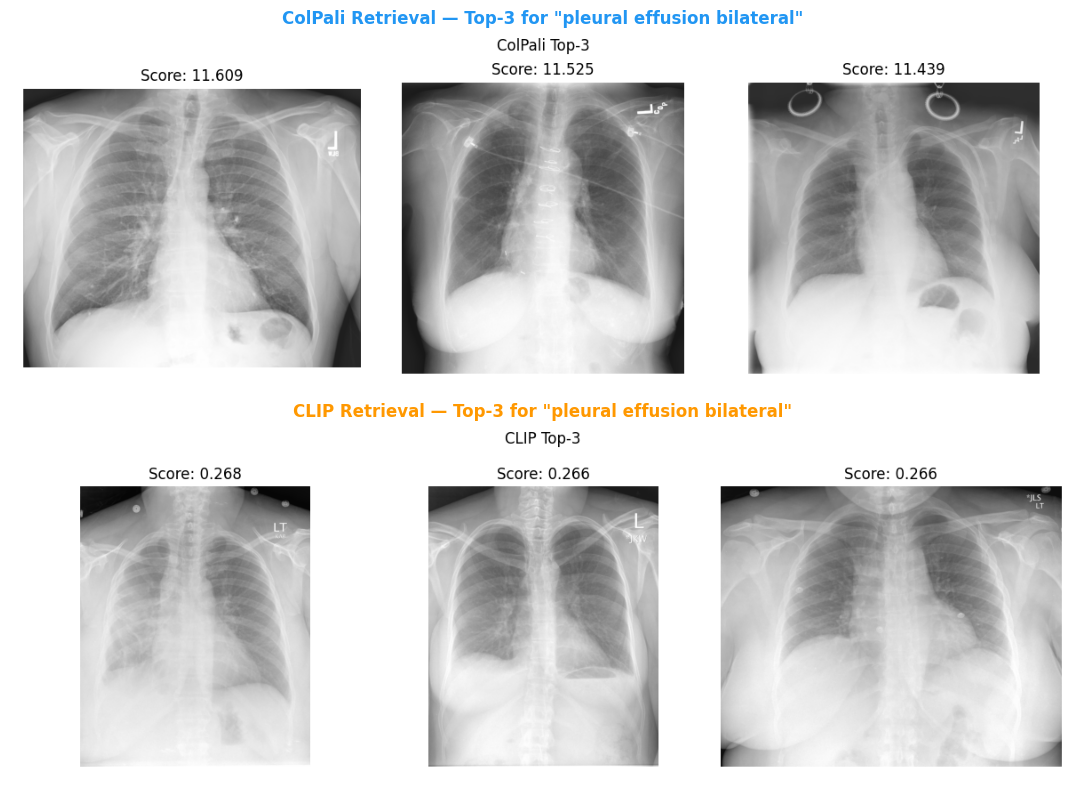

✓ Comparison saved


In [12]:
if colpali_png_path and clip_png_path:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].imshow(Image.open(colpali_png_path))
    axes[0].set_title('ColPali Retrieval — Top-3 for "pleural effusion bilateral"',
                       fontsize=12, fontweight='bold', color='#2196F3')
    axes[0].axis('off')
    
    axes[1].imshow(Image.open(clip_png_path))
    axes[1].set_title('CLIP Retrieval — Top-3 for "pleural effusion bilateral"',
                       fontsize=12, fontweight='bold', color='#FF9800')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(WORKING_DIR, 'retrieval_comparison.png'), dpi=150)
    plt.show()
    print('✓ Comparison saved')
else:
    print('Retrieval PNGs not found - add OUTPUT_IMAGES dataset as input')

## 5. Sample Predicted Reports

In [13]:
predictions_df = pd.read_csv(predictions_path)

print('=== Sample Predicted Reports ===\n')
for i in range(3):
    row = predictions_df.iloc[i]
    print(f'━━━ Study {row["study_id"]} ━━━')
    print(f'\n[GROUND TRUTH]\n{row["reference"]}')
    print(f'\n[ColPali + MedGemma]\n{row["colpali_pred"][:300]}')
    print(f'\n[CLIP + MedGemma]\n{row["clip_pred"][:300]}')
    print(f'\n[MedGemma Direct]\n{row["direct_pred"][:300]}')
    print('\n' + '═' * 80 + '\n')

=== Sample Predicted Reports ===

━━━ Study 3890 ━━━

[GROUND TRUTH]
No acute cardiopulmonary abnormality. .

[ColPali + MedGemma]
FINDINGS:
- Lungs: The lungs are clear without focal consolidation, pleural effusion, or pneumothorax. The heart size is normal. The mediastinum is unremarkable.
- Heart and Mediastinum: The heart size is normal. The mediastinum is unremarkable.
- Pleura: No pleural effusion or pneumothorax.
- Bones

[CLIP + MedGemma]
FINDINGS:
- Lungs: Low lung volumes. No focal consolidation, pleural effusion, or pneumothorax.
- Heart and Mediastinum: Borderline heart size. Calcified aorta.
- Pleura: No pleural effusion.
- Bones and Soft Tissues: No acute bony abnormality. Probable large retrocardiac hiatal hernia.

IMPRESSION:

[MedGemma Direct]
FINDINGS:
- Lungs: The lungs are clear. No focal consolidation, pleural effusion, or pneumothorax is identified.
- Heart and Mediastinum: The heart size is normal. The mediastinal contours are normal.
- Pleura: The pleural spaces

## 6. Sample QA Outputs

In [14]:
qa_results_df = pd.read_csv(qa_results_path)

print('=== Sample QA Predictions (ColPali + MedGemma) ===\n')
for i in range(5):
    row = qa_results_df.iloc[i]
    print(f'Q: {row["question"]}')
    print(f'GT: {row["reference"]}')
    print(f'Pred: {row["prediction"][:200]}')
    print()

=== Sample QA Predictions (ColPali + MedGemma) ===

Q: Is there consolidation visible in this chest X-ray?
GT: No consolidation is observed in the lungs.
Pred: Based on the provided chest X-ray and the retrieved radiology context, there is no consolidation visible. The context states "No acute radiographic cardiopulmonary process" and "No acute cardiopulmona

Q: Can pulmonary consolidation be identified?
GT: No, pulmonary consolidation is not observed. The lungs are free of focal airspace disease.
Pred: Based on the provided chest X-ray and the retrieved context, no pulmonary consolidation can be identified. The image shows normal lung fields without any signs of consolidation.

Q: Are there signs of airspace consolidation?
GT: No, airspace consolidation is not observed. The lungs are free of focal airspace disease.
Pred: Based on the provided chest X-ray and the retrieved radiology context, there are no signs of airspace consolidation. The image shows clear lung fields with no evidenc